In [2]:
# dependencies

from Bio import AlignIO
from Bio import SeqIO
import re
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import numpy as np
import scipy
from matplotlib.colors import LogNorm

In [3]:
# Converting BioCatNet fasta file to dataframe that includes the sequence and the family name

def biocatnet_fasta_to_df(input_fasta):
    data = {'accession': [], 'SFID': [], 'GI': [], 'taxonID': [], 'sequence': []}
    with open(input_fasta) as fp:
        for record in SeqIO.parse(fp, 'fasta'):
            accession = record.id
            sfid = re.findall(r"sfid\|(\d+)", record.id)
            gi = re.findall(r"gi\|(\d+)", record.id)
            taxonID = re.findall(r"taxonID\|(\d+)", record.id)
            sequence = str(record.seq)

            #Attach to dict.
            data['accession'].append(accession)
            data['SFID'].append(", ".join(sfid))
            data['GI'].append(", ".join(gi))
            data['taxonID'].append(", ".join(taxonID))
            data['sequence'].append(sequence)
    df = pd.DataFrame(data)
    return df

In [4]:
biocatnet_r1 = biocatnet_fasta_to_df('/home/alecia/chapter3-repo/output/hmm_search_1/biocatnet/3/ihelixhits_e_0p001_z__T_.fasta')

In [5]:
biocatnet_r1

,accession,SFID,GI,taxonID,sequence
0,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-EDIMAQCF-VFFFAGFETSST--TMTFALLELAQH
1,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH
2,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH
3,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,546684943,77166,-NDIIGQCF-VFFIAGFETSSS--TMTFTMLELAQN
4,sid|85794|pid|63405|hfid|120|sfid|4|gi|3544699...,4,"354469982, 537224038",10029,DKDLRAEVD-TFMFEGHDTTAS--GISWIFYALATH
...,...,...,...,...,...
29032,sid|23655|pid|18144|hfid|732|sfid|98|emb|CAE47...,98,40641242,4565,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN
29033,sid|23713|pid|18186|hfid|732|sfid|98|emb|CDM84...,98,669030166,4565,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN
29034,sid|3756|pid|2450|hfid|1051|sfid|142|gi|493288...,142,493288775,75922,DHQIVTEVL-LLLIGGDETTRH--TLSGGTRQLLRH
29035,sid|106334|pid|81326|hfid|210|sfid|6|gb|AGJ519...,6,478734979,1169899,-NELAAQAF-VFFIAGFETSST--TMTFCLFELASN


In [6]:
# If sequence in I_Helix y, take the acid alcohol - if not, take the acid alcohol in I Helix x

result_data = []

for index, row in biocatnet_r1.iterrows():
    acid = row['sequence'][17]
    alc = row['sequence'][18]

    # Append a dictionary with relevant information to the result_data list
    result_data.append({
        'taxon': row['taxonID'],
        'GI': row['GI'],
        'sequence': row['sequence'],
        'accession': row['accession'],
        'SFID': row['SFID'],
        'acid': acid,
        'alc': alc,
    })


# Create a DataFrame from the result_data list
result_df = pd.DataFrame(result_data)


In [7]:
result_df

,taxon,GI,sequence,accession,SFID,acid,alc
0,77166,546684943,-EDIMAQCF-VFFFAGFETSST--TMTFALLELAQH,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,E,T
1,77166,546684943,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,E,T
2,77166,546684943,-SDIIAQCF-VFFIAGFETSSS--TMTFTMLELAQH,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,E,T
3,77166,546684943,-NDIIGQCF-VFFIAGFETSSS--TMTFTMLELAQN,sid|107075|pid|82008|hfid|211|sfid|6|gb|ERL945...,6,E,T
4,10029,"354469982, 537224038",DKDLRAEVD-TFMFEGHDTTAS--GISWIFYALATH,sid|85794|pid|63405|hfid|120|sfid|4|gi|3544699...,4,D,T
...,...,...,...,...,...,...,...
29032,4565,40641242,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN,sid|23655|pid|18144|hfid|732|sfid|98|emb|CAE47...,98,D,T
29033,4565,669030166,DDTVIGLLW-DMITAGTDTTVI--TVEWAVAELVRN,sid|23713|pid|18186|hfid|732|sfid|98|emb|CDM84...,98,D,T
29034,75922,493288775,DHQIVTEVL-LLLIGGDETTRH--TLSGGTRQLLRH,sid|3756|pid|2450|hfid|1051|sfid|142|gi|493288...,142,E,T
29035,1169899,478734979,-NELAAQAF-VFFIAGFETSST--TMTFCLFELASN,sid|106334|pid|81326|hfid|210|sfid|6|gb|AGJ519...,6,E,T


In [8]:
acidalc = result_df.groupby('acid').alc.value_counts()
acidalc.to_csv('biocatnet_r1_acidalc.csv')

In [ ]:
with open('/home/alecia/chapter3-repo/analysis/biocatnet_heatmap/biocatnet_r1_acidalc.csv') as f:
    biocatnet_acidalc_counts = pd.read_csv(f)

biocatnet_acidalc_counts

,acid,alc,count
0,A,N,147
1,A,T,107
2,A,A,1
3,A,P,1
4,A,V,1
5,D,T,8893
6,D,S,163
7,D,N,102
8,D,A,91
9,D,P,31


In [10]:
heatmap_data = biocatnet_acidalc_counts.pivot(index='alc', columns='acid', values='count')
heatmap_orderedAA = (heatmap_data.reindex(columns=['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .reindex(['E','D','H','K','R','G','P','C','A','I','V','L','M','F','Y','W','Q','S','N','T'])
                     .fillna(0)
)

In [11]:
heatmap_orderedAA

acid,E,D,H,K,R,G,P,C,A,I,V,L,M,F,Y,W,Q,S,N,T
alc,,,,,,,,,,,,,,,,,,,,
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
H,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
K,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
R,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
G,2.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
P,118.0,31.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,3.0,0.0
C,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A,297.0,91.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0


[Text(0.5, 23.52222222222222, 'Acid'),
 Text(50.722222222222214, 0.5, 'Alcohol')]

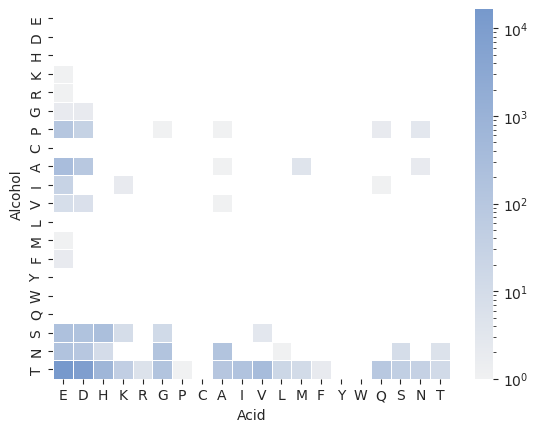

In [15]:
cmap = sns.light_palette("#79C", as_cmap=True)
sns.set_style(style='ticks')
sns.axes_style({'font.sans-serif': 'Arial'})

heatmap = sns.heatmap(
    heatmap_orderedAA,
    norm=LogNorm(),
    linecolor='white',
    linewidths=0.5,
    cmap=cmap
    )

heatmap.set(xlabel="Acid", ylabel="Alcohol")


# cmap = sns.cubehelix_palette(as_cmap=True)

# cluster_map = sns.clustermap(
#     heatmap_orderedAA,
#     norm=LogNorm(),
#     cmap=cmap,
#     # figsize=(5,5),
#     # dendrogram_ratio=(.2, .2)
#     )